In [8]:
from __future__ import annotations

from pathlib import Path
import re
from typing import Dict, Optional


def read_simulation_time(log_file: str | Path) -> Dict[str, Optional[float]]:
    """Read simulation timing information from an md-flexible logOutput file.

    Returns a dictionary with:
    - metric: Which line was parsed ("Total wall-clock time", "Simulate", or "Total accumulated")
    - nanoseconds: Parsed time in ns (float)
    - seconds: Parsed time in s (float)
    - file: Absolute path to the parsed file
    """
    path = Path(log_file).expanduser().resolve()
    text = path.read_text(encoding="utf-8", errors="replace")

    patterns = [
        r"Total wall-clock time\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Simulate\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Total accumulated\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
    ]
    labels = ["Total wall-clock time", "Simulate", "Total accumulated"]

    for label, pattern in zip(labels, patterns):
        match = re.search(pattern, text)
        if match:
            return {
                "metric": label,
                "nanoseconds": float(match.group(1)),
                "seconds": float(match.group(2)),
                "file": str(path),
            }

    raise ValueError(
        f"No known simulation-time pattern found in {path}. Expected one of: "
        "'Total wall-clock time', 'Simulate', or 'Total accumulated'."
    )


# Example:
# result = read_simulation_time(
#     "generated_inputs_rangeCheck/totalParticles_300000/sigmaRatio_0p15/countRatio_2p00/dataLayout_AoS/run_0/logOutput_155157_2.out"
# )
# print(result)


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats as scipy_stats
    _HAS_SCIPY = True
except Exception:
    scipy_stats = None
    _HAS_SCIPY = False


def infer_total_particles_from_input(run_dir: Path) -> int | None:
    """Infer total particles from input.yaml."""
    input_yaml = run_dir / "input.yaml"
    if not input_yaml.exists():
        return None

    total = 0
    pattern = re.compile(r"numberOfParticles\s*:\s*([0-9]+)")
    for line in input_yaml.read_text(encoding="utf-8", errors="replace").splitlines():
        m = pattern.search(line)
        if m:
            total += int(m.group(1))
    return total if total > 0 else None


def parse_prefixed_value(parts: tuple[str, ...], prefix: str) -> str | None:
    """Extract value from a path token of the form '<prefix>_<value>'."""
    token = next((p for p in parts if p.startswith(prefix)), None)
    if token is None:
        return None
    return token.split("_", 1)[1]


def parse_thread_count_from_filename(filename: str) -> int | None:
    """Extract thread count from logOutput filename (e.g., logOutput_..._threads_8.out)."""
    match = re.search(r"_threads_(\d+)\.out$", filename)
    if match:
        return int(match.group(1))
    return None


def collect_runtime_data_strongscaling(base_dir: str | Path = ".") -> pd.DataFrame:
    """Collect simulation times from logOutput files under base_dir recursively, extracting thread count and cell size."""
    base = Path(base_dir).expanduser().resolve()
    rows = []

    for log_path in base.rglob("logOutput_*.out"):
        parts = log_path.parts

        container = parse_prefixed_value(parts, "container_")
        traversal = parse_prefixed_value(parts, "traversal_")
        sigma_ratio_str = parse_prefixed_value(parts, "sigmaRatio_")
        count_ratio_str = parse_prefixed_value(parts, "countRatio_")
        cell_size_str = parse_prefixed_value(parts, "cellSize_")
        run_str = parse_prefixed_value(parts, "run_")

        if None in {container, traversal, sigma_ratio_str, count_ratio_str, run_str}:
            continue

        threads = parse_thread_count_from_filename(log_path.name)
        if threads is None:
            continue

        sigma_ratio = float(sigma_ratio_str.replace("p", "."))
        count_ratio = float(count_ratio_str.replace("p", "."))
        cell_size = float(cell_size_str.replace("p", ".")) if cell_size_str else None
        run = int(run_str)

        total_particles = infer_total_particles_from_input(log_path.parent)
        if total_particles is None:
            continue

        timing = read_simulation_time(log_path)
        rows.append(
            {
                "container": container,
                "traversal": traversal,
                "threads": threads,
                "total_particles": total_particles,
                "sigma_ratio": sigma_ratio,
                "count_ratio": count_ratio,
                "cell_size": cell_size,
                "run": run,
                "seconds": timing["seconds"],
                "log_file": str(log_path),
            }
        )

    return pd.DataFrame(rows)


def t_critical(confidence: float, dof: int) -> float:
    """Two-sided t critical value for a given central confidence and dof."""
    if dof <= 0:
        return 0.0

    p = (1.0 + confidence) / 2.0

    if _HAS_SCIPY:
        return float(scipy_stats.t.ppf(p, dof))

    z_lookup = {
        0.68: 0.994,
        0.86: 1.080,
        0.90: 1.645,
        0.95: 1.960,
        0.99: 2.576,
    }
    return z_lookup.get(round(confidence, 2), 1.96)


def apply_scrbook_11pt_style(use_latex: bool = False):
    """Style settings tuned for thesis figures included at ~\\textwidth in scrbook 11pt."""
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 600,
            "font.size": 9,
            "axes.titlesize": 10,
            "axes.labelsize": 9,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "legend.fontsize": 8,
            "legend.title_fontsize": 8,
            "lines.linewidth": 1.4,
            "lines.markersize": 4.5,
            "axes.grid": True,
            "grid.alpha": 0.3,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "text.usetex": use_latex,
        }
    )


def plot_runtime_vs_threads_all_containers(
    df: pd.DataFrame,
    sigma_ratio: float,
    count_ratio: float,
    ax=None,
    error_mode: str = "t86",
):
    """Plot simulation time vs thread count across all containers with one line per traversal."""
    subset = df[
        (df["sigma_ratio"].round(6).eq(round(sigma_ratio, 6)))
        & (df["count_ratio"].round(6).eq(round(count_ratio, 6)))
    ].copy()

    if subset.empty:
        raise ValueError(
            f"No rows found for sigma_ratio={sigma_ratio!r}, count_ratio={count_ratio!r}."
        )

    summary = (
        subset.groupby(["traversal", "threads"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"), seconds_std=("seconds", "std"), n=("seconds", "count"))
        .sort_values(["traversal", "threads"])
    )
    summary["seconds_std"] = summary["seconds_std"].fillna(0.0)

    if error_mode == "std":
        summary["error"] = summary["seconds_std"]
    else:
        confidence = 0.86 if error_mode == "t86" else 0.95
        summary["se"] = summary["seconds_std"] / summary["n"].pow(0.5)
        summary["tcrit"] = summary["n"].apply(lambda n: t_critical(confidence, int(n - 1)))
        summary["error"] = summary["tcrit"] * summary["se"]

    if ax is None:
        _, ax = plt.subplots(figsize=(6.6, 3.2), constrained_layout=True)

    traversal_order = sorted(summary["traversal"].unique().tolist())
    
    # Define distinct colors with high contrast
    color_palette = [
        "#1f77b4",  # blue
        "#ff7f0e",  # orange
        "#2ca02c",  # green
        "#d62728",  # red
        "#9467bd",  # purple
        "#8c564b",  # brown
        "#e377c2",  # pink
        "#7f7f7f",  # gray
    ]
    
    # Define line styles for additional distinction
    linestyles = ["-", "--", "-.", ":"]
    
    color_map = {t: color_palette[i % len(color_palette)] for i, t in enumerate(traversal_order)}
    linestyle_map = {t: linestyles[i % len(linestyles)] for i, t in enumerate(traversal_order)}

    for traversal in traversal_order:
        grp = summary[summary["traversal"] == traversal].sort_values("threads")
        ax.errorbar(
            grp["threads"],
            grp["seconds_mean"],
            yerr=grp["error"],
            marker="o",
            linestyle=linestyle_map[traversal],
            capsize=3,
            color=color_map[traversal],
            linewidth=2.0,
            markersize=5.5,
            label=traversal,
        )

    ax.set_title(f"Runtime vs Thread Count (sigma={sigma_ratio:.2f}, count={count_ratio:.2f})")
    ax.set_xlabel(r"Thread count")
    ax.set_ylabel(r"Simulation time $t$ in s")
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(title="Traversal", fontsize=8)


Data collected from containers:
container
HierarchicalGrid            [hgrid_block8, hgrid_block4]
HierarchicalGridMatching                [hgrid_matching]
LinkedCells                                     [lc_c08]
Name: traversal, dtype: object

Available thread counts: [1, 2, 4, 8, 14, 28, 56, 112]
Available sigma ratios: [0.5]
Available count ratios: [6.0]
Available cell sizes: [0.5, 1.0]


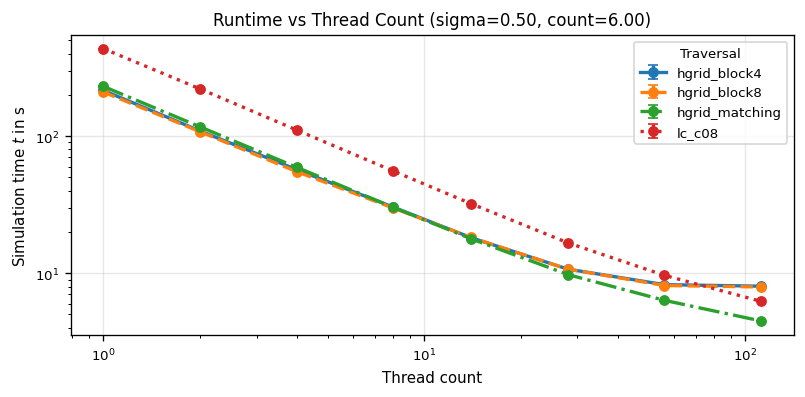

Saved: ../thesis_plots/strongscaling_cellSize_0p50.pdf


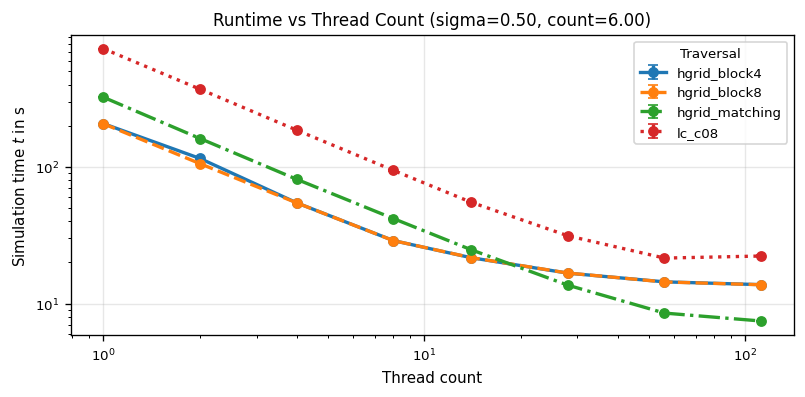

Saved: ../thesis_plots/strongscaling_cellSize_1p00.pdf

Plotted one figure per cell size with traversal lines and Student-t error bars (all containers combined).


In [10]:


# Collect data from all 3 containers and generate plots
runtime_df = collect_runtime_data_strongscaling(".")

apply_scrbook_11pt_style(use_latex=False)

if runtime_df.empty:
    print("No logOutput_*_threads_*.out files found below current directory.")
else:
    print("Data collected from containers:")
    print(runtime_df.groupby("container")["traversal"].unique())
    print("\nAvailable thread counts:", sorted(runtime_df["threads"].unique().tolist()))
    print("Available sigma ratios:", sorted(runtime_df["sigma_ratio"].unique().tolist()))
    print("Available count ratios:", sorted(runtime_df["count_ratio"].unique().tolist()))
    print("Available cell sizes:", sorted(runtime_df["cell_size"].dropna().unique().tolist()))
    
    output_dir = Path("..") / "thesis_plots"
    output_dir.mkdir(exist_ok=True)

    # Generate one plot per cell size
    cell_sizes = sorted(runtime_df["cell_size"].dropna().unique().tolist())
    
    for cell_size in cell_sizes:
        try:
            # Filter data for this cell size
            cell_df = runtime_df[runtime_df["cell_size"] == cell_size].copy()
            
            if cell_df.empty:
                print(f"Skipped cell_size={cell_size}: No data available")
                continue
            
            # Get the first sigma/count combination for this cell size
            first_sigma = cell_df["sigma_ratio"].iloc[0]
            first_count = cell_df["count_ratio"].iloc[0]
            
            fig, ax = plt.subplots(1, 1, figsize=(6.6, 3.2), constrained_layout=True)
            plot_runtime_vs_threads_all_containers(cell_df, first_sigma, first_count, ax=ax, error_mode="t86")
            
            cell_tag = f"{cell_size:.2f}".replace(".", "p")
            pdf_path = output_dir / f"strongscaling_cellSize_{cell_tag}.pdf"
            fig.savefig(pdf_path, bbox_inches="tight")
            plt.show()
            print(f"Saved: {pdf_path}")
        except Exception as e:
            print(f"Skipped cell_size={cell_size}: {e}")

    print("\nPlotted one figure per cell size with traversal lines and Student-t error bars (all containers combined).")


In [ ]:
# Speedup at 56 threads: t(1 thread) / t(56 threads) for each traversal + cell size
if runtime_df.empty:
    print("runtime_df is empty. Run the previous cell first.")
else:
    mean_by_cfg = (
        runtime_df[runtime_df["threads"].isin([1, 56])]
        .groupby(["traversal", "cell_size", "threads"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"), n=("seconds", "count"))
    )

    pivot = mean_by_cfg.pivot_table(
        index=["traversal", "cell_size"],
        columns="threads",
        values="seconds_mean",
        aggfunc="first",
    )

    speedup_df = (
        pivot.rename(columns={1: "seconds_1", 56: "seconds_56"})
        .assign(speedup_56=lambda d: d["seconds_1"] / d["seconds_56"])
        .reset_index()
        .sort_values(["traversal", "cell_size"])
    )

    missing = speedup_df[speedup_df[["seconds_1", "seconds_56"]].isna().any(axis=1)]
    if not missing.empty:
        print("Warning: Missing 1-thread or 56-thread data for some combinations:")
        print(missing[["traversal", "cell_size", "seconds_1", "seconds_56"]].to_string(index=False))

    print("Speedup at 56 threads per traversal + cell size (mean over available runs/containers):")
    print(speedup_df[["traversal", "cell_size", "seconds_1", "seconds_56", "speedup_56"]].to_string(index=False))

    speedup_df

    print("Maybe bigger scenario interesting")

Speedup at 56 threads per traversal + cell size (mean over available runs/containers):
     traversal  cell_size  seconds_1  seconds_56  speedup_56
  hgrid_block4        0.5 215.597333    8.255667   26.115072
  hgrid_block4        1.0 207.662667   14.429000   14.392035
  hgrid_block8        0.5 209.873333    8.136667   25.793527
  hgrid_block8        1.0 207.232333   14.403333   14.387804
hgrid_matching        0.5 230.630333    6.339667   36.378937
hgrid_matching        1.0 323.956333    8.523667   38.006687
        lc_c08        0.5 435.069000    9.649667   45.086428
        lc_c08        1.0 734.535333   21.537667   34.104685
